In [18]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import torch

PROJECT_ROOT = Path.cwd()
RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DATA_DIR = PROJECT_ROOT / "data" / "processed"
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"

print("Python environment ready")
print("Project root:", PROJECT_ROOT)
print("Raw data folder:", RAW_DATA_DIR)

print("\nPyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "VRAM:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

Python environment ready
Project root: C:\Users\tscou\capstone
Raw data folder: C:\Users\tscou\capstone\data\raw

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU
VRAM: 8.0 GB


In [19]:
file_path = RAW_DATA_DIR / "all_tickets_processed_improved_v3.csv"

print("Dataset path:", file_path)
print("File exists:", file_path.exists())

df = pd.read_csv(file_path)

print("\nRows:", df.shape[0])
print("Columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

Dataset path: C:\Users\tscou\capstone\data\raw\all_tickets_processed_improved_v3.csv
File exists: True

Rows: 47837
Columns: 2

Column names:
['Document', 'Topic_group']


In [20]:
df.head()

,Document,Topic_group
0,connection with icon icon dear please setup ic...,Hardware
1,work experience user work experience user hi w...,Access
2,requesting for meeting requesting meeting hi p...,Hardware
3,reset passwords for external accounts re expir...,Access
4,mail verification warning hi has got attached ...,Miscellaneous


In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 47837 entries, 0 to 47836
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Document     47837 non-null  str  
 1   Topic_group  47837 non-null  str  
dtypes: str(2)
memory usage: 14.5 MB


In [22]:
print("Missing values:")
print(df.isna().sum())

print("\nDuplicate rows:")
print(df.duplicated().sum())

Missing values:
Document       0
Topic_group    0
dtype: int64

Duplicate rows:
0


In [23]:
class_counts = df["Topic_group"].value_counts()

print("Number of classes:", df["Topic_group"].nunique())
print("\nClass counts:")
print(class_counts)

Number of classes: 8

Class counts:
Topic_group
Hardware                 13617
HR Support               10915
Access                    7125
Miscellaneous             7060
Storage                   2777
Purchase                  2464
Internal Project          2119
Administrative rights     1760
Name: count, dtype: int64


In [24]:
class_percentages = (
    df["Topic_group"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(class_percentages)

Topic_group
Hardware                 28.47
HR Support               22.82
Access                   14.89
Miscellaneous            14.76
Storage                   5.81
Purchase                  5.15
Internal Project          4.43
Administrative rights     3.68
Name: proportion, dtype: float64


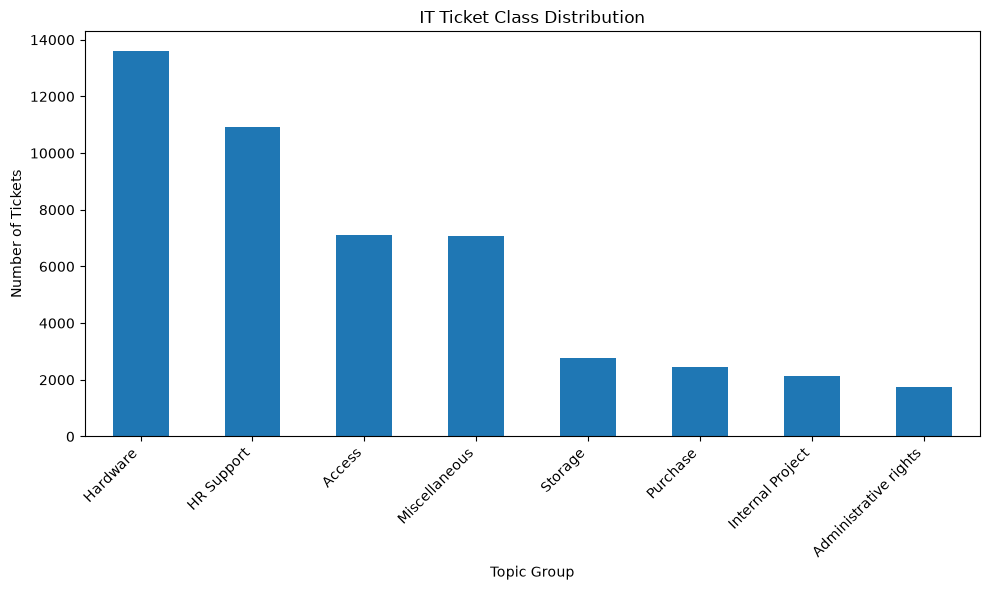

In [25]:
plt.figure(figsize=(10, 6))

class_counts.plot(kind="bar")

plt.title("IT Ticket Class Distribution")
plt.xlabel("Topic Group")
plt.ylabel("Number of Tickets")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.show()

In [26]:
df["char_count"] = df["Document"].astype(str).str.len()
df["word_count"] = df["Document"].astype(str).str.split().str.len()

df[["Document", "Topic_group", "char_count", "word_count"]].head()

,Document,Topic_group,char_count,word_count
0,connection with icon icon dear please setup ic...,Hardware,111,18
1,work experience user work experience user hi w...,Access,124,19
2,requesting for meeting requesting meeting hi p...,Hardware,93,14
3,reset passwords for external accounts re expir...,Access,948,145
4,mail verification warning hi has got attached ...,Miscellaneous,115,15
